# Clustering de Embeddings KG + Análisis Cruzado

Este notebook complementa `embeddings_pipeline.ipynb` con un análisis no supervisado:

1. Carga los embeddings RDF2Vec leakage-free serializados por `embeddings_pipeline.ipynb`.
2. Calcula flags de hipótesis de auditoría (Q1, Q2, Q3) ejecutando las queries SPARQL sobre el TTL via `rdflib`.
3. Añade la etiqueta de gravedad real (`accident_greu`) desde `T_UNIFIED`.
4. Aplica **HDBSCAN** para descubrir grupos estructurales en el espacio de embeddings.
5. Visualiza con **UMAP** 2D.
6. Genera **perfiles explicables** por cluster: atributos dominantes, odds ratio vs. Q1-Q3 y gravedad.
7. Identifica **medoides** (expedientes prototipo) y expedientes de borde.
8. Entrena un **árbol surrogate** interpretable que aproxima los clusters con features legibles.

**Nota metodológica:** los clusters reflejan *similitud estructural en el grafo RDF*, no fraude verificado.
Los flags Q1–Q3 son *hipótesis de auditoría*, no etiquetas de fraude. La gravedad es un outcome
observado independiente del clustering.

**Prerequisito:** ejecutar primero `embeddings_pipeline.ipynb` para generar
`outputs/embeddings.npy` y `outputs/embeddings_index.csv`.

## 1. Imports y carga de embeddings

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import duckdb
import rdflib
from rdflib import Graph
import hdbscan
import umap
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")

# Paths
KG_PATH   = "kg_accidentes_bcn.ttl"
DB_PATH   = "../exploit_zone/exploit_zone.db"
OUT_DIR   = "outputs"
FIG_DIR   = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Cargar embeddings serializados
emb_matrix = np.load(os.path.join(OUT_DIR, "embeddings.npy"))
index_df   = pd.read_csv(os.path.join(OUT_DIR, "embeddings_index.csv"))

print(f"Embeddings cargados: {emb_matrix.shape}  ({len(index_df):,} accidentes, {emb_matrix.shape[1]} dims)")

/home/pau/Desktop/FIB/IA/3_2/BDA/P1/BCN-Meteorologics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Embeddings cargados: (7741, 64)  (7,741 accidentes, 64 dims)


## 2. Flags de auditoría Q1, Q2, Q3 via rdflib

Ejecutamos las tres queries SPARQL directamente sobre el TTL en memoria.
Cada query devuelve un conjunto de `AccidentID` que disparan la hipótesis.

- **Q1**: mismo lugar + misma fecha/hora → posible duplicado de parte.
- **Q2**: mismo perfil (edad+sexo+vehículo) en múltiples accidentes del mismo lugar → posible anillo.
- **Q3**: incoherencia tipo de accidente vs. conteos de víctimas → error de datos o manipulación.

In [2]:
print(f"Cargando grafo RDF desde {KG_PATH}  (puede tardar ~1 min)...")
g = Graph()
g.parse(KG_PATH, format="turtle")
print(f"Grafo cargado: {len(g):,} triples")

Cargando grafo RDF desde kg_accidentes_bcn.ttl  (puede tardar ~1 min)...
Grafo cargado: 265,197 triples


In [3]:
def load_query(fname):
    with open(os.path.join("sparql_pipeline", "queries", fname)) as f:
        return f.read()

def split_ids(concat_str):
    """Descompone GROUP_CONCAT separado por ', ' en lista de IDs limpios."""
    return [s.strip() for s in str(concat_str).split(",") if s.strip()]

# --- Q1: duplicados espacio-temporales ---
q1_ids = set()
for row in g.query(load_query("Q1_duplicate_reports.rq")):
    q1_ids.update(split_ids(row.expedientes))
print(f"Q1 — accidentes en grupos duplicados: {len(q1_ids)}")

# --- Q2: coparticipación repetida de perfil ---
q2_ids = set()
for row in g.query(load_query("Q2_repeat_coparticipation.rq")):
    q2_ids.update(split_ids(row.expedientes))
print(f"Q2 — accidentes con perfil coparticipante repetido: {len(q2_ids)}")

# --- Q3: incoherencia tipo vs. conteos ---
q3_ids = set()
for row in g.query(load_query("Q3_severity_inconsistency.rq")):
    q3_ids.add(str(row.id).strip())
print(f"Q3 — accidentes con incoherencia tipo/conteos: {len(q3_ids)}")

# Añadir flags al dataframe base
df = index_df.copy()
df["flag_Q1"]    = df["numero_expedient"].isin(q1_ids)
df["flag_Q2"]    = df["numero_expedient"].isin(q2_ids)
df["flag_Q3"]    = df["numero_expedient"].isin(q3_ids)
df["flag_any_Q"] = df["flag_Q1"] | df["flag_Q2"] | df["flag_Q3"]

print(f"\nResumen de flags en los {len(df):,} accidentes con embedding:")
print(df[["flag_Q1", "flag_Q2", "flag_Q3", "flag_any_Q"]].sum().to_string())

Q1 — accidentes en grupos duplicados: 38
Q2 — accidentes con perfil coparticipante repetido: 462
Q3 — accidentes con incoherencia tipo/conteos: 0

Resumen de flags en los 7,741 accidentes con embedding:
flag_Q1        38
flag_Q2       462
flag_Q3         0
flag_any_Q    492


## 3. Flag de gravedad y features tabulares

Cargamos `T_UNIFIED` de DuckDB para obtener:
- `accident_greu`: 1 si hubo al menos 1 muerte o lesionado grave (target real, no usado en walks).
- Features interpretables para el árbol surrogate y los perfiles de cluster.

In [4]:
con    = duckdb.connect(DB_PATH)
df_tab = con.execute("""
    SELECT
        numero_expedient,
        numero_morts,
        numero_lesionats_greus,
        numero_lesionats_lleus,
        nom_districte,
        nom_barri,
        hora_dia,
        descripcio_dia_setmana,
        desc_tipus_vehicle_implicat,
        descripcio_motiu_desplacament_conductor
    FROM T_UNIFIED
""").fetchdf()
con.close()

df_tab["accident_greu"] = (
    (df_tab["numero_morts"] > 0) | (df_tab["numero_lesionats_greus"] > 0)
).astype(int)

# Nº de personas por expediente (proxy de fan-out del grafo)
n_personas = df_tab.groupby("numero_expedient").size().rename("n_personas")
df_tab_unique = (
    df_tab
    .sort_values("numero_expedient")
    .drop_duplicates(subset="numero_expedient")
    .merge(n_personas.reset_index(), on="numero_expedient", how="left")
)

df = df.merge(df_tab_unique[[
    "numero_expedient", "accident_greu", "nom_districte", "nom_barri",
    "hora_dia", "descripcio_dia_setmana",
    "desc_tipus_vehicle_implicat", "descripcio_motiu_desplacament_conductor",
    "n_personas"
]], on="numero_expedient", how="left")

print(f"Expedientes con gravedad conocida: {df['accident_greu'].notna().sum():,}")
print(f"  Graves (accident_greu=1): {int(df['accident_greu'].sum())}")
print(f"  No graves:               {int((df['accident_greu']==0).sum())}")

Expedientes con gravedad conocida: 7,599
  Graves (accident_greu=1): 252
  No graves:               7347


## 4. HDBSCAN — Clustering en espacio de embeddings

Normalizamos los embeddings (StandardScaler) y aplicamos HDBSCAN, que:
- Determina el número de clusters **automáticamente** por densidad.
- Asigna `cluster_id = -1` a puntos de baja densidad (*ruido* / outliers).
- Provee `probabilities_`: confianza de pertenencia de cada punto a su cluster.

In [5]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(emb_matrix)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,          # ~0.4% de 7741 accidentes
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)
labels = clusterer.fit_predict(X_scaled)
probs  = clusterer.probabilities_

df["cluster_id"]   = labels
df["cluster_prob"] = probs

n_clusters = int(labels.max()) + 1
n_noise    = int((labels == -1).sum())

print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos de ruido (-1): {n_noise} ({100*n_noise/len(labels):.1f}%)")
print("\nTamaño por cluster:")
print(pd.Series(labels).value_counts().sort_index().to_string())
print("\nNota: Cluster 1 (Sarrià/Horta/Nou Barris, OR_Q2~1) es de baja señal —")
print("probablemente inducido por la relación CloserStation (misma estación meteorológica).")
print("Tratar con cautela; los clusters relevantes son 0, 2, 3 y 4.")

Clusters encontrados: 5
Puntos de ruido (-1): 7439 (96.1%)

Tamaño por cluster:
-1    7439
 0      36
 1      57
 2      92
 3      66
 4      51

Nota: Cluster 1 (Sarrià/Horta/Nou Barris, OR_Q2~1) es de baja señal —
probablemente inducido por la relación CloserStation (misma estación meteorológica).
Tratar con cautela; los clusters relevantes son 0, 2, 3 y 4.


## 5. UMAP 2D — Visualización

Reducimos a 2D para explorar la estructura visual de los clusters y superponer las señales
de auditoría y gravedad.

In [6]:
print("Calculando proyección UMAP 2D (puede tardar ~1-2 min)...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
emb_2d  = reducer.fit_transform(X_scaled)

df["umap_x"] = emb_2d[:, 0]
df["umap_y"] = emb_2d[:, 1]
print("UMAP calculado.")

Calculando proyección UMAP 2D (puede tardar ~1-2 min)...
UMAP calculado.


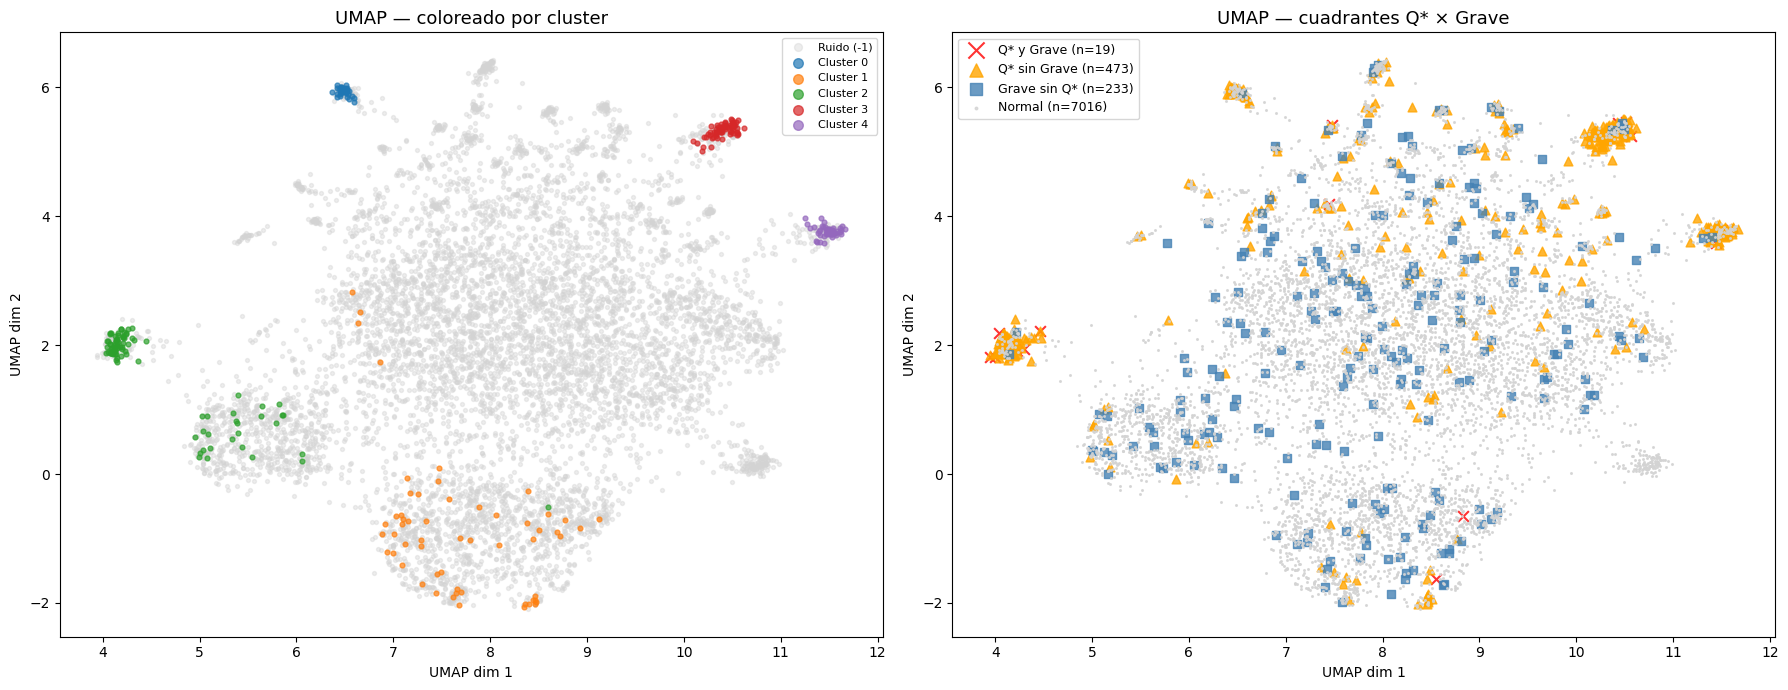

Figuras guardadas en outputs/figures


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Panel izquierdo: coloreado por cluster_id ---
ax = axes[0]
unique_labels = sorted(df["cluster_id"].unique())
palette = sns.color_palette("tab10", n_colors=max(1, len([l for l in unique_labels if l >= 0])))

# Ruido en gris
mask_noise = df["cluster_id"] == -1
ax.scatter(
    df.loc[mask_noise, "umap_x"], df.loc[mask_noise, "umap_y"],
    c="lightgrey", s=8, alpha=0.4, label="Ruido (-1)"
)
# Clusters con color
for i, cid in enumerate([l for l in unique_labels if l >= 0]):
    mask = df["cluster_id"] == cid
    ax.scatter(
        df.loc[mask, "umap_x"], df.loc[mask, "umap_y"],
        s=12, alpha=0.7, color=palette[i], label=f"Cluster {cid}"
    )
ax.set_title("UMAP — coloreado por cluster", fontsize=13)
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.legend(markerscale=2, fontsize=8, loc="best")

# --- Panel derecho: cuadrantes Q* × grave ---
ax = axes[1]
conditions = {
    "Q* y Grave":     ( df["flag_any_Q"] &  (df["accident_greu"] == 1), "red",        "x", 60),
    "Q* sin Grave":   ( df["flag_any_Q"] & ~(df["accident_greu"] == 1), "orange",     "^", 40),
    "Grave sin Q*":   (~df["flag_any_Q"] &  (df["accident_greu"] == 1), "steelblue",  "s", 30),
    "Normal":         (~df["flag_any_Q"] & ~(df["accident_greu"] == 1), "lightgrey",  ".",  6),
}
for label, (mask, color, marker, size) in conditions.items():
    ax.scatter(
        df.loc[mask, "umap_x"], df.loc[mask, "umap_y"],
        c=color, marker=marker, s=size, alpha=0.8, label=f"{label} (n={mask.sum()})"
    )
ax.set_title("UMAP — cuadrantes Q* × Grave", fontsize=13)
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.legend(markerscale=1.5, fontsize=9, loc="best")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "umap_clusters.png"), dpi=150)
plt.savefig(os.path.join(FIG_DIR, "umap_quadrants.png"), dpi=150)
plt.show()
print("Figuras guardadas en", FIG_DIR)

## 6. Perfil estadístico por cluster

Para cada cluster calculamos:
- Tamaño y % del total.
- % y conteos para cada flag (Q1, Q2, Q3, any_Q) y para `accident_greu`.
- **Odds Ratio (OR)** vs. población global: OR > 2 indica enriquecimiento significativo.
- Atributos dominantes: top-3 distritos, top-1 tipo de vehículo, mediana hora del día y nº personas.

Los clusters de ruido (`-1`) se tratan como grupo separado.

In [8]:
def odds_ratio(p_cluster, p_global, n_cluster, n_global):
    """OR = (p_c/(1-p_c)) / (p_g/(1-p_g)), con suavizado de Laplace."""
    eps = 1e-6
    a = p_cluster + eps;  b = 1 - p_cluster + eps
    c = p_global  + eps;  d = 1 - p_global  + eps
    return (a / b) / (c / d)

def top_values(series, n=3):
    return ", ".join(series.dropna().value_counts().head(n).index.astype(str).tolist())

n_total = len(df)
global_rates = {
    "Q1":    df["flag_Q1"].mean(),
    "Q2":    df["flag_Q2"].mean(),
    "Q3":    df["flag_Q3"].mean(),
    "any_Q": df["flag_any_Q"].mean(),
    "grave": df["accident_greu"].fillna(0).mean(),
}

rows = []
cluster_labels = sorted(df["cluster_id"].unique())

for cid in cluster_labels:
    sub = df[df["cluster_id"] == cid]
    n   = len(sub)
    label = f"Cluster {cid}" if cid >= 0 else "Outliers (-1)"

    row = {"cluster": label, "n": n, "pct_total": 100 * n / n_total}
    for flag, col in [("Q1", "flag_Q1"), ("Q2", "flag_Q2"), ("Q3", "flag_Q3"),
                      ("any_Q", "flag_any_Q")]:
        cnt = int(sub[col].sum())
        p   = cnt / n
        row[f"n_{flag}"]  = cnt
        row[f"pct_{flag}"] = round(100 * p, 1)
        row[f"OR_{flag}"]  = round(odds_ratio(p, global_rates[flag], n, n_total), 2)

    grave_cnt = int(sub["accident_greu"].fillna(0).sum())
    p_grave   = grave_cnt / n
    row["n_grave"]   = grave_cnt
    row["pct_grave"] = round(100 * p_grave, 1)
    row["OR_grave"]  = round(odds_ratio(p_grave, global_rates["grave"], n, n_total), 2)

    row["top_distritos"]  = top_values(sub["nom_districte"])
    row["top_vehiculo"]   = top_values(sub["desc_tipus_vehicle_implicat"], 1)
    row["med_hora"]       = round(sub["hora_dia"].median(), 0) if sub["hora_dia"].notna().any() else None
    row["med_n_personas"] = round(sub["n_personas"].median(), 1) if sub["n_personas"].notna().any() else None

    rows.append(row)

profiles = pd.DataFrame(rows)
profiles.to_csv(os.path.join(OUT_DIR, "cluster_profiles.csv"), index=False)
print("Perfil estadístico por cluster (guardado en outputs/cluster_profiles.csv):")

display_cols = ["cluster", "n", "pct_total",
                "n_Q1", "pct_Q1", "OR_Q1",
                "n_Q2", "pct_Q2", "OR_Q2",
                "n_Q3", "pct_Q3", "OR_Q3",
                "n_any_Q", "pct_any_Q", "OR_any_Q",
                "n_grave", "pct_grave", "OR_grave",
                "top_distritos", "top_vehiculo", "med_hora", "med_n_personas"]
display(profiles[display_cols])

Perfil estadístico por cluster (guardado en outputs/cluster_profiles.csv):


,cluster,n,pct_total,n_Q1,pct_Q1,OR_Q1,n_Q2,pct_Q2,OR_Q2,n_Q3,...,n_any_Q,pct_any_Q,OR_any_Q,n_grave,pct_grave,OR_grave,top_distritos,top_vehiculo,med_hora,med_n_personas
0,Outliers (-1),7439,96.098695,28,0.4,0.77,325,4.4,0.72,0,...,350,4.7,0.73,243,3.3,1.00,"Eixample, Sant Martí, Sants-Montjuïc",Turisme,14.0,2.0
1,Cluster 0,36,0.465056,1,2.8,5.79,14,38.9,10.03,0,...,15,41.7,10.52,0,0.0,0.00,"Eixample, Sant Martí, Sants-Montjuïc",Motocicleta,14.0,2.0
2,Cluster 1,57,0.736339,0,0.0,0.00,3,5.3,0.88,0,...,3,5.3,0.82,2,3.5,1.08,"Sarrià-Sant Gervasi, Horta-Guinardó, Nou Barris",Turisme,14.0,2.0
3,Cluster 2,92,1.188477,4,4.3,9.21,38,41.3,11.09,0,...,39,42.4,10.84,4,4.3,1.35,"Les Corts, Eixample, Sants-Montjuïc",Turisme,14.0,2.0
4,Cluster 3,66,0.852603,3,4.5,9.65,52,78.8,58.52,0,...,53,80.3,60.07,1,1.5,0.46,"Eixample, Sant Martí, Sants-Montjuïc",Turisme,14.0,2.0
5,Cluster 4,51,0.658830,2,3.9,8.27,30,58.8,22.51,0,...,32,62.7,24.81,2,3.9,1.21,"Eixample, Sant Martí",Motocicleta,14.0,2.0


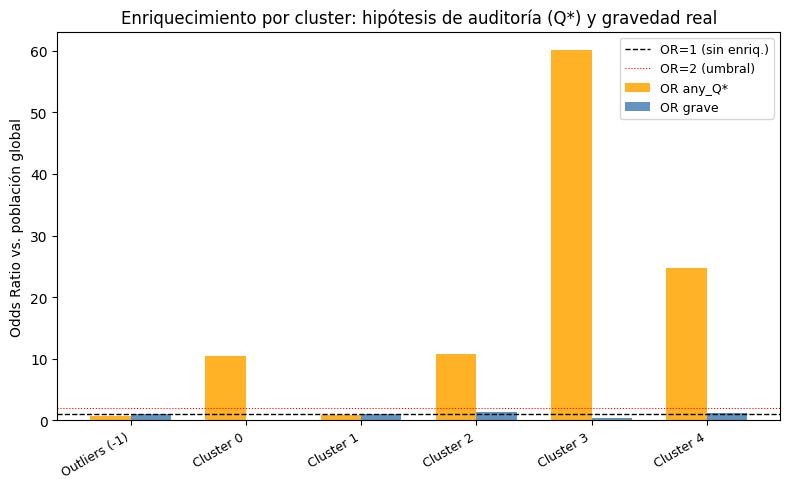

In [9]:
# Gráfico de barras: OR_any_Q y OR_grave por cluster
fig, ax = plt.subplots(figsize=(max(8, len(profiles) * 1.2), 5))

x     = np.arange(len(profiles))
width = 0.35
bars1 = ax.bar(x - width/2, profiles["OR_any_Q"],  width, label="OR any_Q*",  color="orange",    alpha=0.85)
bars2 = ax.bar(x + width/2, profiles["OR_grave"],   width, label="OR grave",   color="steelblue", alpha=0.85)

ax.axhline(1.0, color="black",  linewidth=1.0, linestyle="--", label="OR=1 (sin enriq.)")
ax.axhline(2.0, color="red",    linewidth=0.8, linestyle=":",  label="OR=2 (umbral)")
ax.set_xticks(x)
ax.set_xticklabels(profiles["cluster"].tolist(), rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Odds Ratio vs. población global")
ax.set_title("Enriquecimiento por cluster: hipótesis de auditoría (Q*) y gravedad real")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "cluster_profiles_bar.png"), dpi=150)
plt.show()

## 7. Medoides y expedientes de borde

Para cada cluster con enriquecimiento notable (OR_any_Q > 2 o OR_grave > 2) y para los outliers:
- **Medoide**: expediente más representativo (mínima suma de distancias al resto del cluster).
- **Expedientes de borde**: los 2 con probabilidad de pertenencia más baja (más atípicos dentro del cluster).

In [10]:
INTERESTING_OR_THRESHOLD = 2.0

# Clusters interesantes: OR_any_Q > umbral, OR_grave > umbral, o outliers
interesting = profiles[
    (profiles["OR_any_Q"] > INTERESTING_OR_THRESHOLD) |
    (profiles["OR_grave"] > INTERESTING_OR_THRESHOLD) |
    (profiles["cluster"] == "Outliers (-1)")
]["cluster"].tolist()

print(f"Clusters de interés (OR>2 o outliers): {interesting}\n")

ficha_cols = ["numero_expedient", "nom_districte", "nom_barri",
              "hora_dia", "desc_tipus_vehicle_implicat",
              "n_personas", "flag_Q1", "flag_Q2", "flag_Q3", "flag_any_Q", "accident_greu"]

medoid_records = []

for label in interesting:
    if label == "Outliers (-1)":
        cid = -1
    else:
        cid = int(label.replace("Cluster ", ""))

    sub      = df[df["cluster_id"] == cid].copy()
    sub_idxs = sub.index.tolist()

    if len(sub_idxs) == 0:
        continue

    sub_emb = X_scaled[sub_idxs]

    print(f"{'='*60}")
    print(f"  {label}  (n={len(sub)})")
    print(f"{'='*60}")

    if cid == -1:
        # Para outliers: mostrar los que disparan alguna flag Q*
        q_outliers = sub[sub["flag_any_Q"] == True]
        if len(q_outliers) > 0:
            print(f"  Outliers con flag_any_Q=True ({len(q_outliers)} de {len(sub)}):")
            display(q_outliers[ficha_cols].head(10))
        else:
            print("  Ningún outlier dispara Q1/Q2/Q3 — revisar muestra aleatoria:")
            display(sub[ficha_cols].sample(min(5, len(sub)), random_state=42))
        continue

    # Medoide: mínima suma de distancias intra-cluster
    dist_matrix = euclidean_distances(sub_emb)
    medoid_pos  = int(np.argmin(dist_matrix.sum(axis=1)))
    medoid_idx  = sub_idxs[medoid_pos]
    medoid_row  = df.loc[medoid_idx]

    print("  MEDOIDE (expediente más representativo):")
    display(df.loc[[medoid_idx], ficha_cols])
    medoid_records.append({"cluster": label, "tipo": "medoide",
                            "numero_expedient": medoid_row["numero_expedient"]})

    # Expedientes de borde: menor cluster_prob
    borde = sub.nsmallest(2, "cluster_prob")
    print("  EXPEDIENTES DE BORDE (pertenencia más débil):")
    display(borde[ficha_cols])
    print()

Clusters de interés (OR>2 o outliers): ['Outliers (-1)', 'Cluster 0', 'Cluster 2', 'Cluster 3', 'Cluster 4']

  Outliers (-1)  (n=7439)
  Outliers con flag_any_Q=True (350 de 7439):


,numero_expedient,nom_districte,nom_barri,hora_dia,desc_tipus_vehicle_implicat,n_personas,flag_Q1,flag_Q2,flag_Q3,flag_any_Q,accident_greu
160,2025S000094,Gràcia,el Camp d'en Grassot i Gràcia Nova,20.0,Turisme,1.0,False,True,False,True,0.0
190,2025S000319,Eixample,la Dreta de l'Eixample,12.0,Motocicleta,1.0,False,True,False,True,0.0
313,2025S001138,Eixample,el Fort Pienc,14.0,Motocicleta,1.0,False,True,False,True,0.0
334,2025S001289,Eixample,la Dreta de l'Eixample,8.0,Turisme,1.0,False,True,False,True,0.0
359,2025S001446,Eixample,el Fort Pienc,18.0,Motocicleta,1.0,False,True,False,True,0.0
452,2025S002135,Eixample,la Dreta de l'Eixample,9.0,Motocicleta,1.0,False,True,False,True,0.0
495,2025S002378,Eixample,el Fort Pienc,10.0,Motocicleta,1.0,False,True,False,True,0.0
528,2025S002558,Sants-Montjuïc,la Marina de Port,16.0,Turisme,1.0,False,True,False,True,0.0
530,2025S002573,Eixample,el Fort Pienc,11.0,Motocicleta,1.0,False,True,False,True,0.0
660,2025S003311,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",8.0,Altres vehicles amb motor,1.0,True,False,False,True,0.0


  Cluster 0  (n=36)
  MEDOIDE (expediente más representativo):


,numero_expedient,nom_districte,nom_barri,hora_dia,desc_tipus_vehicle_implicat,n_personas,flag_Q1,flag_Q2,flag_Q3,flag_any_Q,accident_greu
2159,2025S001216,Sant Martí,el Camp de l'Arpa del Clot,12.0,Turisme,2.0,False,True,False,True,0.0


  EXPEDIENTES DE BORDE (pertenencia más débil):


...

,numero_expedient,nom_districte,nom_barri,hora_dia,desc_tipus_vehicle_implicat,n_personas,flag_Q1,flag_Q2,flag_Q3,flag_any_Q,accident_greu
1753,2025S000592,Eixample,la Dreta de l'Eixample,0.0,Motocicleta,2.0,False,True,False,True,0.0
4513,2025S004868,Eixample,el Fort Pienc,0.0,Turisme,2.0,False,True,False,True,0.0



  Cluster 4  (n=51)
  MEDOIDE (expediente más representativo):


,numero_expedient,nom_districte,nom_barri,hora_dia,desc_tipus_vehicle_implicat,n_personas,flag_Q1,flag_Q2,flag_Q3,flag_any_Q,accident_greu
5571,2025S006513,Eixample,la Dreta de l'Eixample,19.0,Turisme,2.0,False,False,False,False,0.0


  EXPEDIENTES DE BORDE (pertenencia más débil):


,numero_expedient,nom_districte,nom_barri,hora_dia,desc_tipus_vehicle_implicat,n_personas,flag_Q1,flag_Q2,flag_Q3,flag_any_Q,accident_greu
4243,2025S004442,Eixample,la Dreta de l'Eixample,14.0,Motocicleta,2.0,True,False,False,True,0.0
2585,2025S001816,Eixample,l'Antiga Esquerra de l'Eixample,8.0,Bicicleta,2.0,False,True,False,True,0.0


## 8. Árbol surrogate interpretable

Entrenamos un árbol de decisión que predice `cluster_id` a partir de features legibles
(no de los embeddings). El árbol **aproxima** los clusters con reglas tipo *si–entonces*.

**Importante:** la accuracy del surrogate mide *en qué medida features interpretables
reconstruyen el cluster*, no si el cluster es correcto.
Si la accuracy es baja (< 0.6), los clusters no se explican bien con las features tabulares
disponibles — lo que significa que el KG aporta información estructural adicional.

In [11]:
USE_SURROGATE = True   # poner False para omitir

if USE_SURROGATE:
    # Features interpretables (solo accidentes asignados a un cluster real, no ruido)
    df_surr = df[df["cluster_id"] >= 0].copy()

    surrogate_features = ["hora_dia", "n_personas"]
    categorical_surr   = ["nom_districte", "desc_tipus_vehicle_implicat",
                          "descripcio_dia_setmana", "descripcio_motiu_desplacament_conductor"]

    df_surr = df_surr[surrogate_features + categorical_surr + ["cluster_id"]].dropna()

    # Encode categoricals
    for col in categorical_surr:
        le = LabelEncoder()
        df_surr[col] = le.fit_transform(df_surr[col].astype(str))

    X_surr = df_surr[surrogate_features + categorical_surr].values
    y_surr = df_surr["cluster_id"].values
    feature_names = surrogate_features + categorical_surr

    dt = DecisionTreeClassifier(max_depth=4, random_state=42, min_samples_leaf=20)
    dt.fit(X_surr, y_surr)

    acc = accuracy_score(y_surr, dt.predict(X_surr))
    print(f"Accuracy del árbol surrogate (train): {acc:.3f}")
    if acc < 0.6:
        print("  → Accuracy baja: los clusters capturan estructura del KG que las features tabulares no recogen bien.")
    else:
        print("  → Accuracy razonable: las features tabulares aproximan los clusters aceptablemente.")

    print("\nReglas del árbol surrogate (aproximación, no explicación causal):")
    print(export_text(dt, feature_names=feature_names))
else:
    print("USE_SURROGATE=False — árbol surrogate omitido.")

Accuracy del árbol surrogate (train): 0.570
  → Accuracy baja: los clusters capturan estructura del KG que las features tabulares no recogen bien.

Reglas del árbol surrogate (aproximación, no explicación causal):
|--- nom_districte <= 0.50
|   |--- desc_tipus_vehicle_implicat <= 7.50
|   |   |--- class: 0
|   |--- desc_tipus_vehicle_implicat >  7.50
|   |   |--- desc_tipus_vehicle_implicat <= 10.00
|   |   |   |--- descripcio_dia_setmana <= 3.50
|   |   |   |   |--- class: 4
|   |   |   |--- descripcio_dia_setmana >  3.50
|   |   |   |   |--- class: 4
|   |   |--- desc_tipus_vehicle_implicat >  10.00
|   |   |   |--- descripcio_dia_setmana <= 2.50
|   |   |   |   |--- class: 3
|   |   |   |--- descripcio_dia_setmana >  2.50
|   |   |   |   |--- class: 3
|--- nom_districte >  0.50
|   |--- nom_districte <= 6.50
|   |   |--- nom_districte <= 4.50
|   |   |   |--- desc_tipus_vehicle_implicat <= 13.50
|   |   |   |   |--- class: 2
|   |   |   |--- desc_tipus_vehicle_implicat >  13.50
|   

## 9. Lista de revisión prioritaria

Expedientes que acumulan las tres señales de riesgo simultáneamente:
- Pertenecen a un **cluster con OR_any_Q > 2** (patrón estructural en el KG)
- Tienen al menos un **flag Q* activo** (regla de auditoría disparada)
- El accidente fue clasificado como **grave** (`accident_greu = 1`)

Este cruce minimiza falsos positivos: el cluster aporta contexto estructural,
el flag aporta la regla explícita, y la gravedad justifica la prioridad de revisión.

In [12]:
HIGH_OR_THRESHOLD = 2.0

# Clusters con señal de auditoría relevante
high_signal_clusters = profiles.loc[
    profiles["OR_any_Q"] > HIGH_OR_THRESHOLD, "cluster"
].tolist()

# Cruce de las tres condiciones
mask_cluster = df["cluster_id"].map(
    lambda c: (f"Cluster {c}" if c >= 0 else "Outliers (-1)") in high_signal_clusters
)
mask_q       = df["flag_any_Q"] == True
mask_grave   = df["accident_greu"] == 1

priority_df = df[mask_cluster & mask_q & mask_grave].copy()
priority_df = priority_df.sort_values("cluster_prob", ascending=False)

priority_cols = [
    "numero_expedient", "cluster_id", "cluster_prob",
    "flag_Q1", "flag_Q2", "flag_Q3",
    "nom_districte", "nom_barri", "hora_dia", "n_personas",
    "desc_tipus_vehicle_implicat"
]
priority_df = priority_df[priority_cols]

print(f"Expedientes en lista de revisión prioritaria: {len(priority_df)}")
print(f"  - En clusters de alta señal (OR_Q*>{HIGH_OR_THRESHOLD}): {mask_cluster.sum()}")
print(f"  - Con flag Q* activo: {(mask_cluster & mask_q).sum()}")
print(f"  - Con accidente grave: {(mask_cluster & mask_q & mask_grave).sum()}")
print()
display(priority_df)

priority_df.to_csv(os.path.join(OUT_DIR, "priority_review.csv"), index=False)
print(f"\nGuardado en {OUT_DIR}/priority_review.csv")

Expedientes en lista de revisión prioritaria: 5
  - En clusters de alta señal (OR_Q*>2.0): 245
  - Con flag Q* activo: 139
  - Con accidente grave: 5



,numero_expedient,cluster_id,cluster_prob,flag_Q1,flag_Q2,flag_Q3,nom_districte,nom_barri,hora_dia,n_personas,desc_tipus_vehicle_implicat
6702,2025S002588,4,1.000000,False,True,False,Eixample,la Dreta de l'Eixample,9.0,3.0,Motocicleta
5828,2025S006918,2,0.997011,True,True,False,Eixample,la Dreta de l'Eixample,18.0,2.0,Motocicleta
6785,2025S003269,3,0.986155,False,True,False,Eixample,la Dreta de l'Eixample,7.0,3.0,Turisme
7414,2025S000978,4,0.984035,False,True,False,Eixample,la Nova Esquerra de l'Eixample,5.0,4.0,Turisme
2303,2025S001419,2,0.980624,False,True,False,Les Corts,la Maternitat i Sant Ramon,14.0,2.0,Turisme



Guardado en outputs/priority_review.csv


## 10. Tabla resumen y guardado de asignaciones

Guardamos las asignaciones cluster por expediente con todos los flags para análisis posterior.

In [13]:
out_cols = ["numero_expedient", "cluster_id", "cluster_prob",
            "flag_Q1", "flag_Q2", "flag_Q3", "flag_any_Q", "accident_greu",
            "nom_districte", "nom_barri", "hora_dia", "n_personas",
            "desc_tipus_vehicle_implicat", "umap_x", "umap_y"]

df[out_cols].to_csv(os.path.join(OUT_DIR, "cluster_assignments.csv"), index=False)
print(f"Asignaciones guardadas en {OUT_DIR}/cluster_assignments.csv  ({len(df):,} filas)")

# Resumen narrativo de clusters de interés
print("\n" + "="*70)
print("RESUMEN DE CLUSTERS (OR > 2 en any_Q o grave)")
print("="*70)
interesting_profiles = profiles[
    (profiles["OR_any_Q"] > INTERESTING_OR_THRESHOLD) |
    (profiles["OR_grave"] > INTERESTING_OR_THRESHOLD)
]
for _, row in interesting_profiles.iterrows():
    q_signal  = "candidato a auditoría" if row["OR_any_Q"] > INTERESTING_OR_THRESHOLD else ""
    grav_sig  = "alto riesgo vial"      if row["OR_grave"] > INTERESTING_OR_THRESHOLD else ""
    signals   = " + ".join(filter(None, [q_signal, grav_sig]))
    print(f"  {row['cluster']:15s}  n={int(row['n']):4d} | "
          f"OR_Q*={row['OR_any_Q']:.2f} OR_grave={row['OR_grave']:.2f} | "
          f"{row['top_vehiculo']} | {row['top_distritos'].split(',')[0]} | "
          f"hora_med={row['med_hora']} | [{signals}]")

print("\nNota: los clusters reflejan similitud estructural en el KG, no fraude verificado.")
print("Los flags Q* son hipótesis de auditoría. La gravedad es un outcome observado independiente.")

Asignaciones guardadas en outputs/cluster_assignments.csv  (7,741 filas)

RESUMEN DE CLUSTERS (OR > 2 en any_Q o grave)
  Cluster 0        n=  36 | OR_Q*=10.52 OR_grave=0.00 | Motocicleta | Eixample | hora_med=14.0 | [candidato a auditoría]
  Cluster 2        n=  92 | OR_Q*=10.84 OR_grave=1.35 | Turisme | Les Corts | hora_med=14.0 | [candidato a auditoría]
  Cluster 3        n=  66 | OR_Q*=60.07 OR_grave=0.46 | Turisme | Eixample | hora_med=14.0 | [candidato a auditoría]
  Cluster 4        n=  51 | OR_Q*=24.81 OR_grave=1.21 | Motocicleta | Eixample | hora_med=14.0 | [candidato a auditoría]

Nota: los clusters reflejan similitud estructural en el KG, no fraude verificado.
Los flags Q* son hipótesis de auditoría. La gravedad es un outcome observado independiente.
